In [1]:
%run -i ../../python_scripts/nb_setup.py

GPU Available: False


#### Choose the dataset you want to use :
* must be data the model did not see at training
* first column : __y_true__ $\in \{0,1\}$ are the samples labels  
* second column : __y_pred__ are the predicted class of samples ($\in \{0,1\}$ too)
* third column : __kappa_f__ is confidence function for each sample, $\in \mathbb{R}$

In [2]:
sgp_df_SR = pickle.load(open("sgp_set_cnn", "rb"))
print(
    "N =",
    sgp_df_SR.shape[0],
    "Proportion of 1s: ",
    np.round(sgp_df_SR.y_true.sum() / sgp_df_SR.shape[0], 2),
)
sgp_df_SR.head(3)

N = 6788 Proportion of 1s:  0.33


,y_true,y_pred,kappa
0,0.0,0.0,0.985617
1,1.0,1.0,0.899486
2,1.0,1.0,0.952112


In [3]:
sgp_df_MCD = pickle.load(open("sgp_set_cnn_MCD", "rb"))
sgp_df_MCD.head(3)

,y_true,y_pred,kappa
0,0.0,0.0,-0.000600
1,1.0,1.0,-0.003494
2,1.0,1.0,-0.001536


In [4]:
num_targets = 100  # number of targets r* to consider when drawing metric/coverage of metric/theta curves
theta_min_SR, theta_max_SR = 0.5, 1  # Sn-independent grid
theta_min_MCD, theta_max_MCD = -0.05, 0  # Sn-independent grid

Plot lines configuration 

In [5]:
lines_list_1_SR, lines_list_2_SR, lines_list_1_MCD, lines_list_2_MCD, lines_list_2 = (
    lines()
)

## 1. __Unconditional risks__
Dichotomy search for upper bound

### 1.1. __0/1 risk__

In [6]:
# we restricted after checking the bounds in joint_control_*.ipynb ; without prior knowledge just search over [0,1] with a higher num_targets
metric_targets = np.linspace(0.02, 0.13, num=num_targets)

In [7]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=18
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
train_set_MCD, test_set_MCD = train_test_split(
    sgp_df_MCD, seed=18
)  # same with MCD kappa confidence function
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    mode="dicho",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
results_MCD = sgp_at_targets(
    train_set_MCD,
    test_set_MCD,
    metric_targets=metric_targets,
    mode="dicho",
    theta_min=theta_min_MCD,
    theta_max=theta_max_MCD,
)
all_results = {"SR": results_SR, "MCD": results_MCD}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

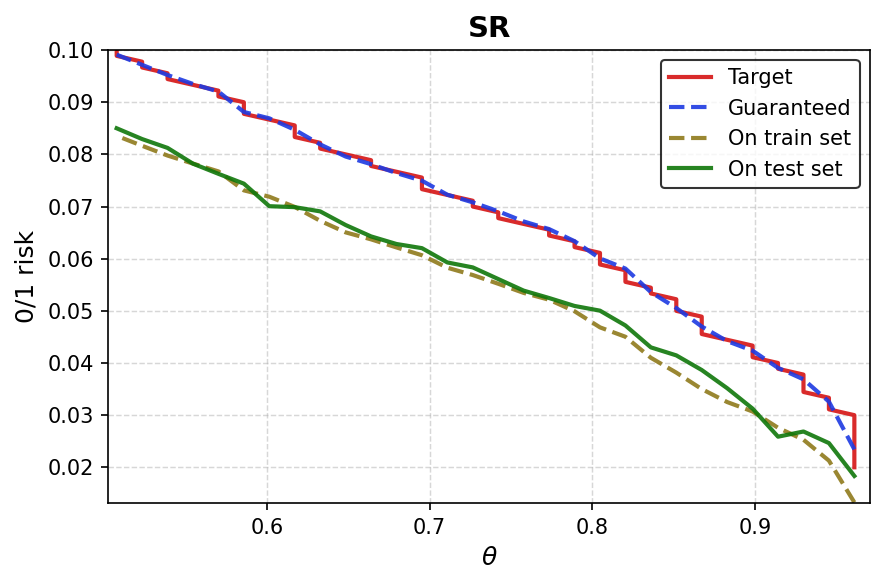

In [8]:
metric_plots(
    all_results,
    metric="0/1 risk",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * min(results_SR.theta_star), 1.01 * max(results_SR.theta_star)],
    ylim=[
        0.99 * min(min(results_SR.test_metric), min(results_SR.train_metric)),
        1.01 * max(results_SR.metric_bound),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

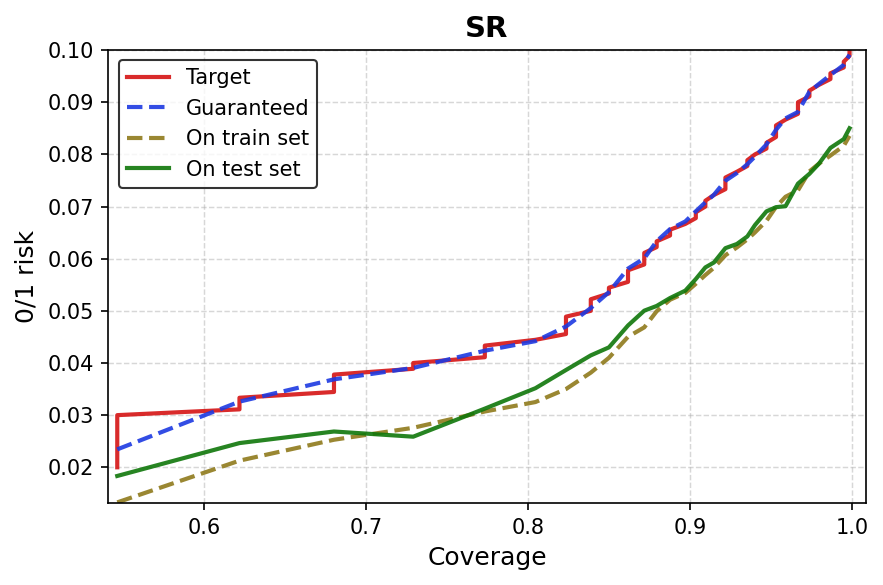

In [9]:
metric_plots(
    all_results,
    metric="0/1 risk",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[
        0.99 * min(min(results_SR.test_metric), min(results_SR.train_metric)),
        1.01 * max(results_SR.metric_bound),
    ],
    title="SR",
)

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

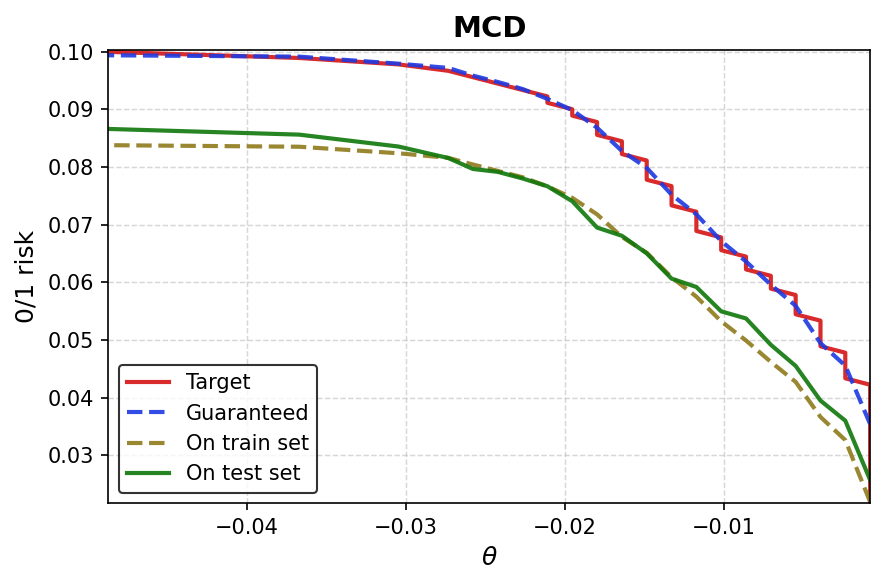

In [10]:
metric_plots(
    all_results,
    metric="0/1 risk",
    lines_list=lines_list_1_MCD,
    xlim=[0.99 * min(results_MCD.theta_star), 1.01 * max(results_MCD.theta_star)],
    ylim=[
        0.99 * min(min(results_MCD.test_metric), min(results_MCD.train_metric)),
        1.01 * max(results_MCD.metric_bound),
    ],
    title="MCD",
)

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

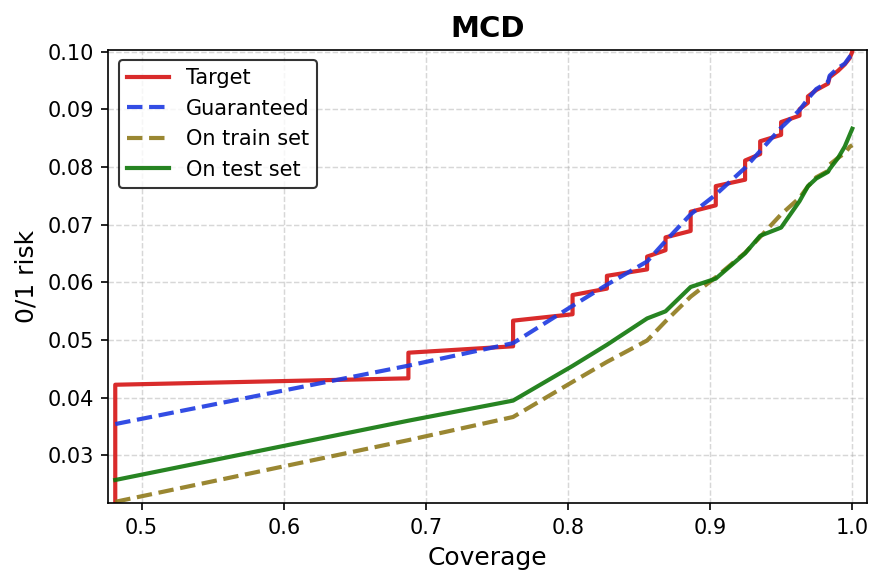

In [11]:
metric_plots(
    all_results,
    metric="0/1 risk",
    lines_list=lines_list_2_MCD,
    xlim=[0.99 * min(results_MCD.test_coverage), 1.01 * max(results_MCD.test_coverage)],
    ylim=[
        0.99 * min(min(results_MCD.test_metric), min(results_MCD.train_metric)),
        1.01 * max(results_MCD.metric_bound),
    ],
    title="MCD",
)

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

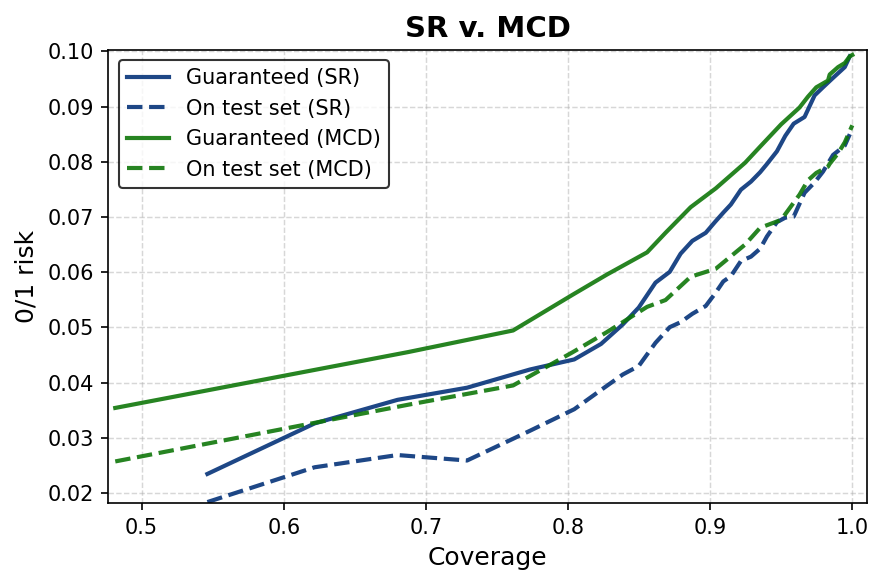

In [12]:
metric_plots(
    all_results,
    metric="0/1 risk",
    lines_list=lines_list_2,
    xlim=[
        0.99 * min(min(results_SR.test_coverage), min(results_MCD.test_coverage)),
        1.01 * max(max(results_MCD.test_coverage), max(results_SR.test_coverage)),
    ],
    ylim=[
        0.99 * min(min(results_MCD.test_metric), min(results_SR.test_metric)),
        1.01 * max(max(results_MCD.metric_bound), max(results_SR.metric_bound)),
    ],
    title="SR v. MCD",
)

### 1.2. __FP risk__

In [13]:
metric_targets = np.linspace(0.001, 0.12, num=num_targets)

In [14]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=19
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
train_set_MCD, test_set_MCD = train_test_split(sgp_df_MCD, seed=19)
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="FP",
    mode="dicho",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
results_MCD = sgp_at_targets(
    train_set_MCD,
    test_set_MCD,
    metric_targets=metric_targets,
    metric="FP",
    mode="dicho",
    theta_min=theta_min_MCD,
    theta_max=theta_max_MCD,
)
all_results = {"SR": results_SR, "MCD": results_MCD}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

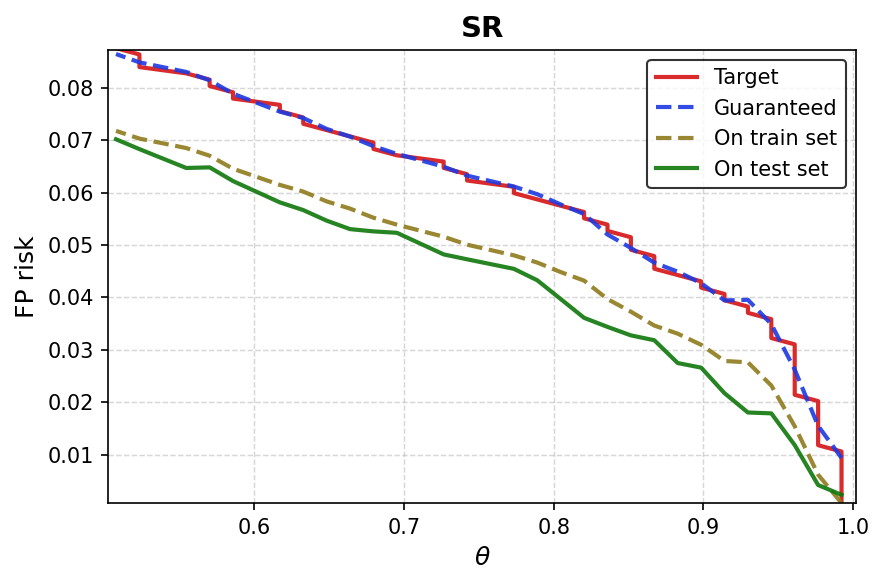

In [15]:
metric_plots(
    all_results,
    metric="FP risk",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * min(results_SR.theta_star), 1.01 * max(results_SR.theta_star)],
    ylim=[
        0.99 * min(min(results_SR.test_metric), min(results_SR.train_metric)),
        1.01 * max(results_SR.metric_bound),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

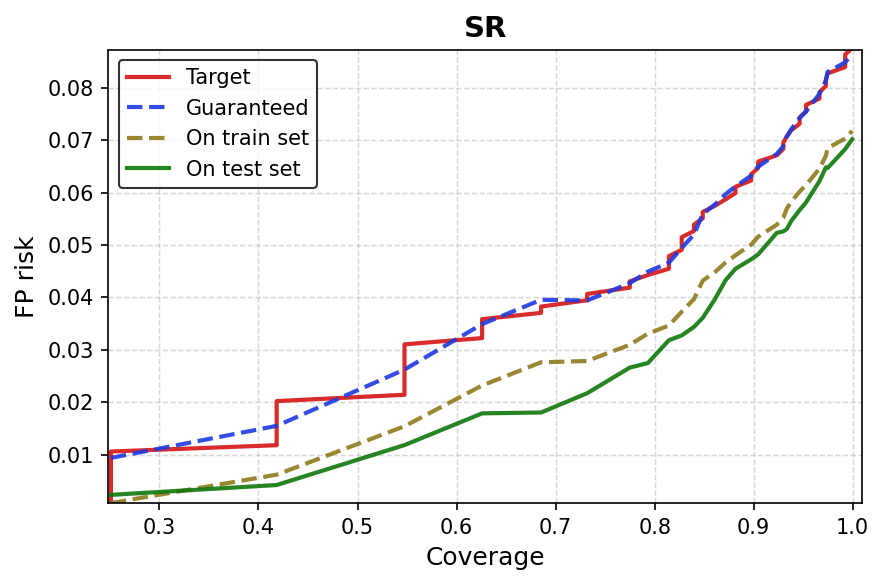

In [16]:
metric_plots(
    all_results,
    metric="FP risk",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[
        0.99 * min(min(results_SR.test_metric), min(results_SR.train_metric)),
        1.01 * max(results_SR.metric_bound),
    ],
    title="SR",
)

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

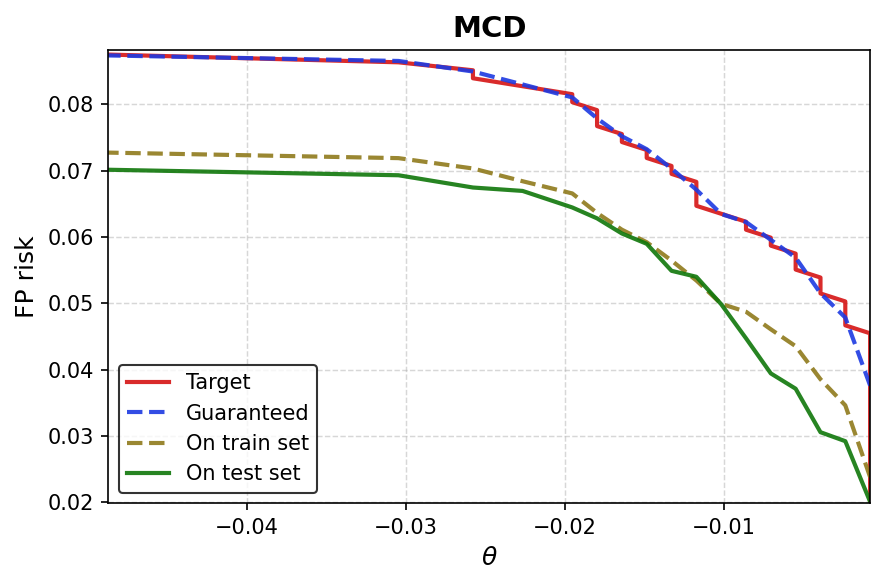

In [17]:
metric_plots(
    all_results,
    metric="FP risk",
    lines_list=lines_list_1_MCD,
    xlim=[0.99 * min(results_MCD.theta_star), 1.01 * max(results_MCD.theta_star)],
    ylim=[
        0.99 * min(min(results_MCD.test_metric), min(results_MCD.train_metric)),
        1.01 * max(results_MCD.metric_bound),
    ],
    title="MCD",
)

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

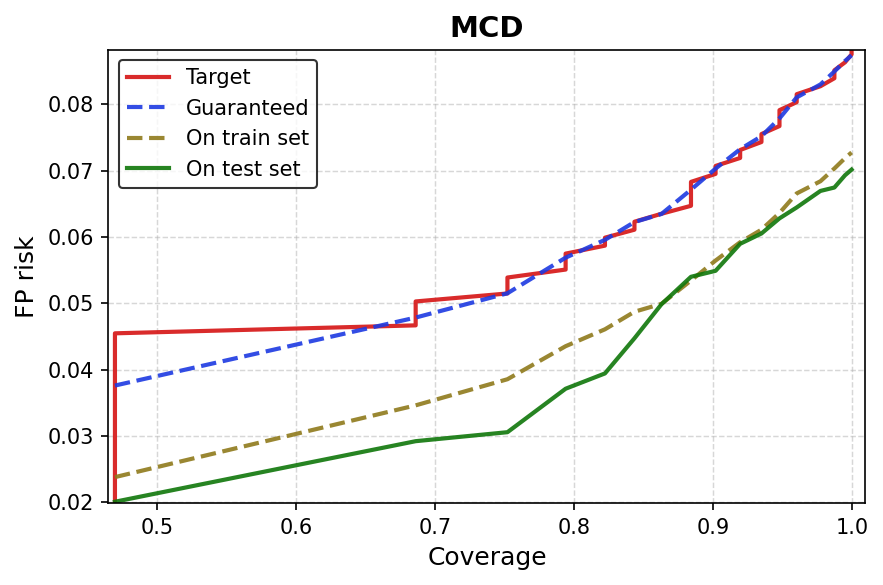

In [18]:
metric_plots(
    all_results,
    metric="FP risk",
    lines_list=lines_list_2_MCD,
    xlim=[0.99 * min(results_MCD.test_coverage), 1.01 * max(results_MCD.test_coverage)],
    ylim=[
        0.99 * min(min(results_MCD.test_metric), min(results_MCD.train_metric)),
        1.01 * max(results_MCD.metric_bound),
    ],
    title="MCD",
)

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

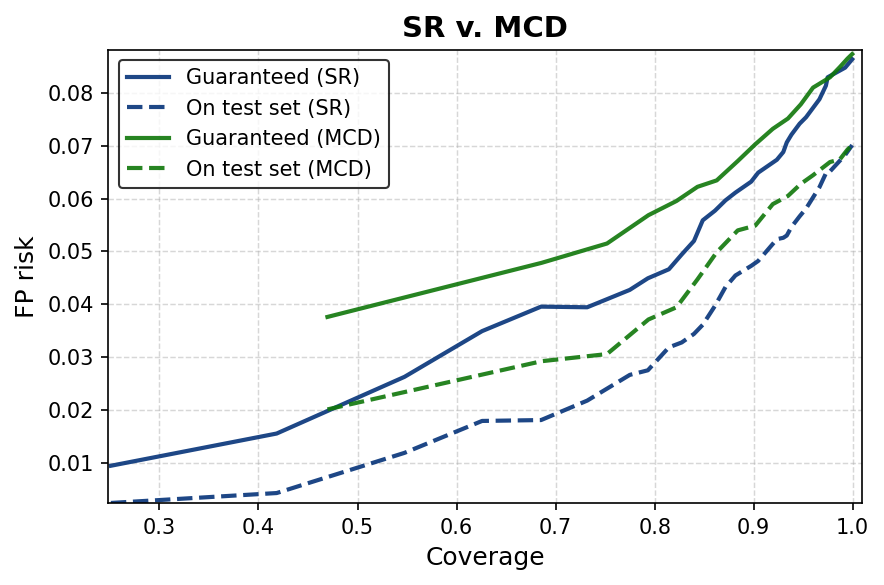

In [19]:
metric_plots(
    all_results,
    metric="FP risk",
    lines_list=lines_list_2,
    xlim=[
        0.99 * min(min(results_SR.test_coverage), min(results_MCD.test_coverage)),
        1.01 * max(max(results_MCD.test_coverage), max(results_SR.test_coverage)),
    ],
    ylim=[
        0.99 * min(min(results_MCD.test_metric), min(results_SR.test_metric)),
        1.01 * max(max(results_MCD.metric_bound), max(results_SR.metric_bound)),
    ],
    title="SR v. MCD",
)

### 1.3. __FN risk__

In [20]:
metric_targets = np.linspace(0.0001, 0.02, num=num_targets)

In [21]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=20
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
train_set_MCD, test_set_MCD = train_test_split(
    sgp_df_MCD, seed=20
)  # same with MCD kappa confidence function
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="FN",
    mode="dicho",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
results_MCD = sgp_at_targets(
    train_set_MCD,
    test_set_MCD,
    metric_targets=metric_targets,
    metric="FN",
    mode="dicho",
    theta_min=theta_min_MCD,
    theta_max=theta_max_MCD,
)
all_results = {"SR": results_SR, "MCD": results_MCD}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

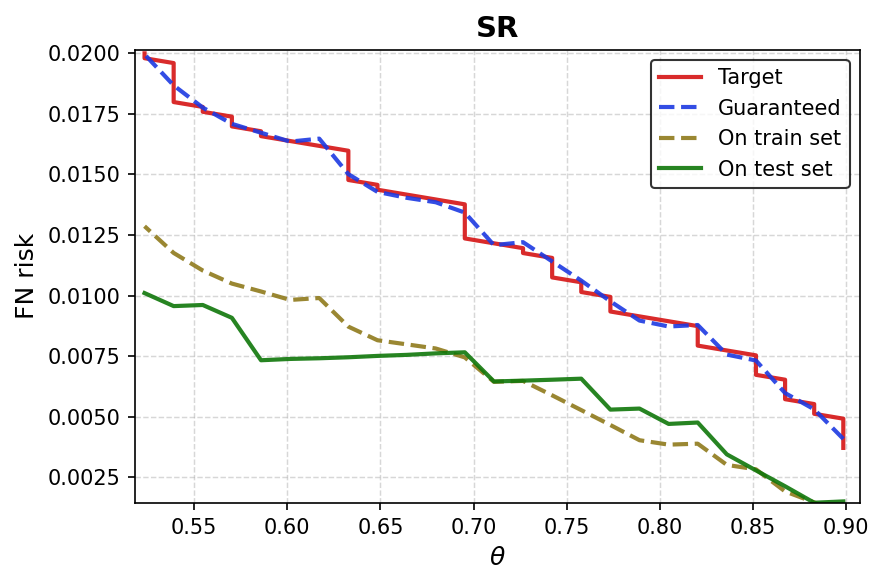

In [22]:
metric_plots(
    all_results,
    metric="FN risk",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * min(results_SR.theta_star), 1.01 * max(results_SR.theta_star)],
    ylim=[0.99 * min(results_SR.test_metric), 1.01 * max(results_SR.metric_bound)],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

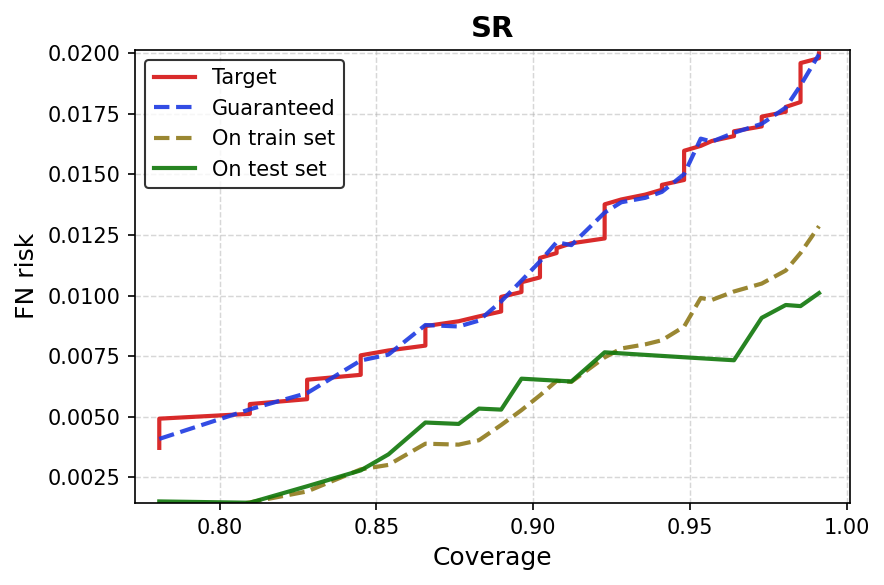

In [23]:
metric_plots(
    all_results,
    metric="FN risk",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[0.99 * min(results_SR.test_metric), 1.01 * max(results_SR.metric_bound)],
    title="SR",
)

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

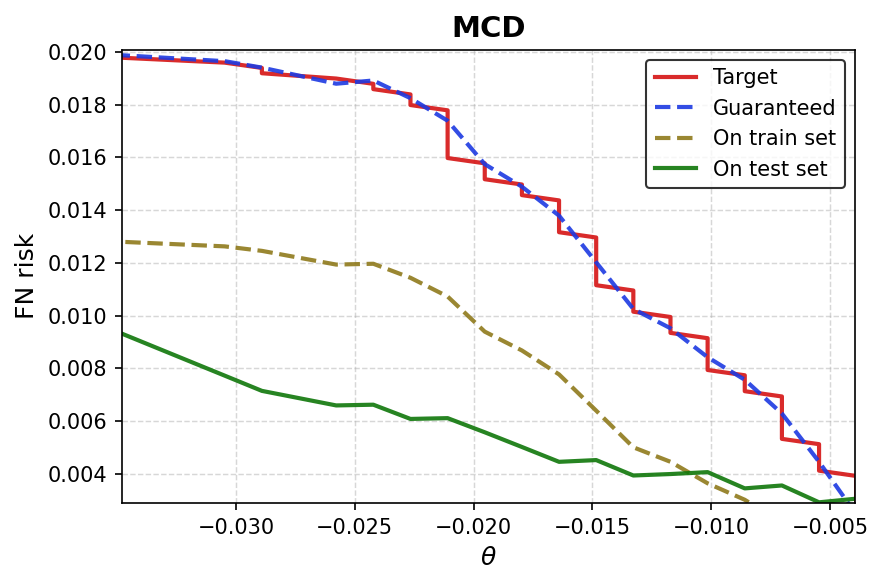

In [24]:
metric_plots(
    all_results,
    metric="FN risk",
    lines_list=lines_list_1_MCD,
    xlim=[0.99 * min(results_MCD.theta_star), 1.01 * max(results_MCD.theta_star)],
    ylim=[0.99 * min(results_MCD.test_metric), 1.01 * max(results_MCD.metric_bound)],
    title="MCD",
)

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

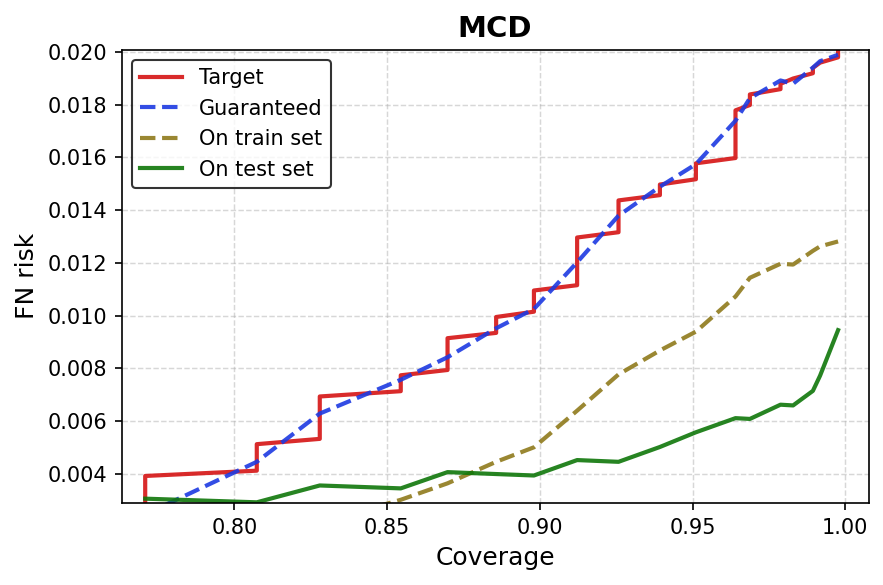

In [25]:
metric_plots(
    all_results,
    metric="FN risk",
    lines_list=lines_list_2_MCD,
    xlim=[0.99 * min(results_MCD.test_coverage), 1.01 * max(results_MCD.test_coverage)],
    ylim=[0.99 * min(results_MCD.test_metric), 1.01 * max(results_MCD.metric_bound)],
    title="MCD",
)

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

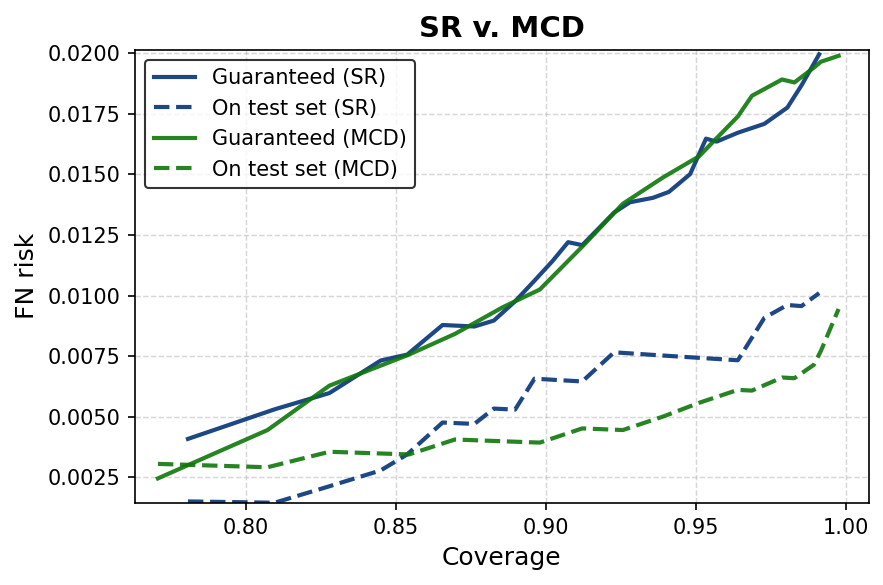

In [26]:
metric_plots(
    all_results,
    metric="FN risk",
    lines_list=lines_list_2,
    xlim=[
        0.99 * min(min(results_SR.test_coverage), min(results_MCD.test_coverage)),
        1.01 * max(max(results_MCD.test_coverage), max(results_SR.test_coverage)),
    ],
    ylim=[
        0.99 * min(min(results_MCD.test_metric), min(results_SR.test_metric)),
        1.01 * max(max(results_MCD.metric_bound), max(results_SR.metric_bound)),
    ],
    title="SR v. MCD",
)

## __2. Conditional metrics__

### 2.1. __FPR__

In [27]:
metric_targets = np.linspace(0.001, 0.2, num=num_targets)

In [28]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=21
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
train_set_MCD, test_set_MCD = train_test_split(
    sgp_df_MCD, seed=21
)  # same with MCD kappa confidence function
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="FPR",
    mode="greedy",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
results_MCD = sgp_at_targets(
    train_set_MCD,
    test_set_MCD,
    metric_targets=metric_targets,
    metric="FPR",
    mode="greedy",
    theta_min=theta_min_MCD,
    theta_max=theta_max_MCD,
)
all_results = {"SR": results_SR, "MCD": results_MCD}

KeyboardInterrupt: 

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

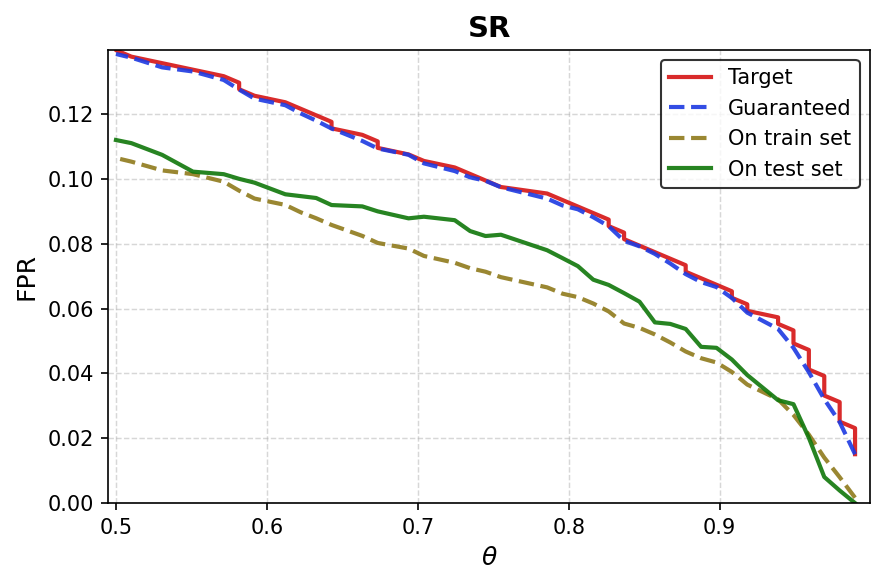

In [ ]:
metric_plots(
    all_results,
    metric="FPR",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * min(results_SR.theta_star), 1.01 * max(results_SR.theta_star)],
    ylim=[0.99 * min(results_SR.test_metric), 1.01 * max(results_SR.metric_bound)],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

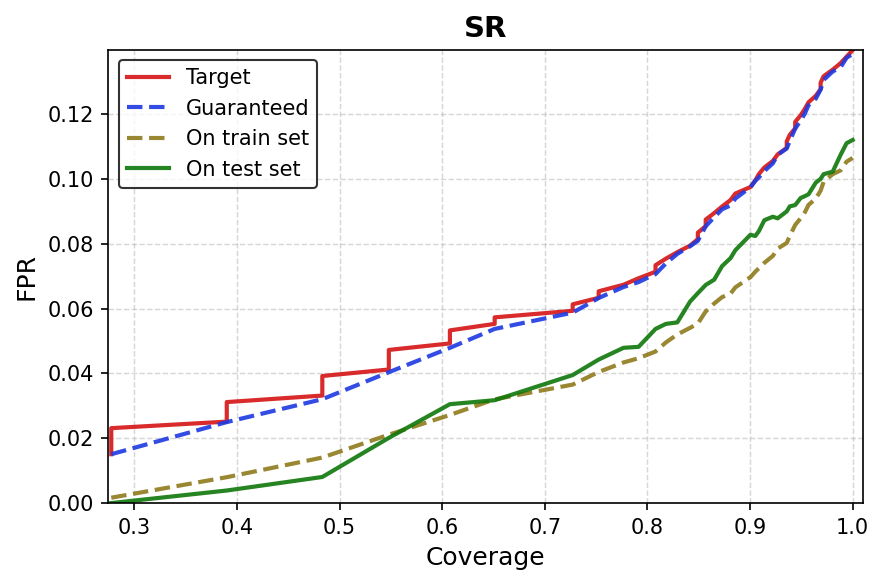

In [ ]:
metric_plots(
    all_results,
    metric="FPR",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[0.99 * min(results_SR.test_metric), 1.01 * max(results_SR.metric_bound)],
    title="SR",
)

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

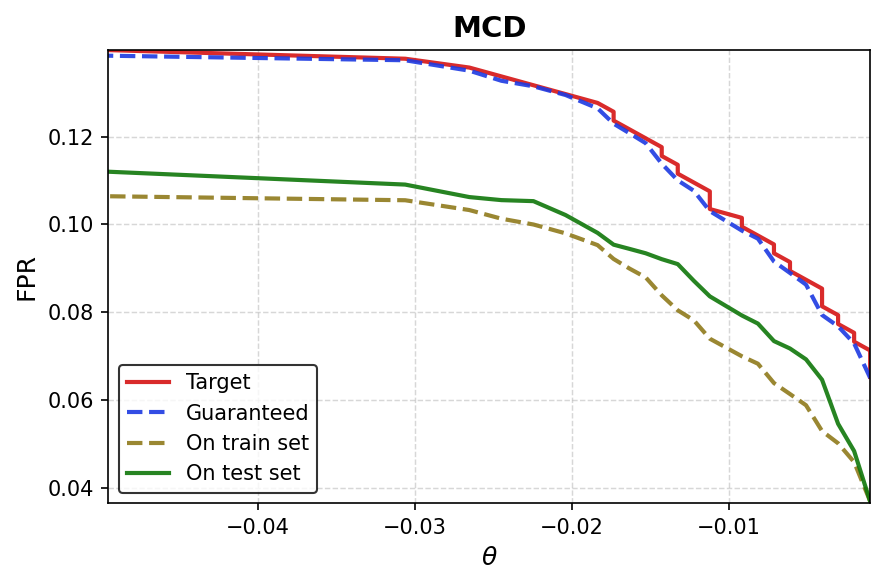

In [ ]:
metric_plots(
    all_results,
    metric="FPR",
    lines_list=lines_list_1_MCD,
    xlim=[0.99 * min(results_MCD.theta_star), 1.01 * max(results_MCD.theta_star)],
    ylim=[0.99 * min(results_MCD.test_metric), 1.01 * max(results_MCD.metric_bound)],
    title="MCD",
)

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

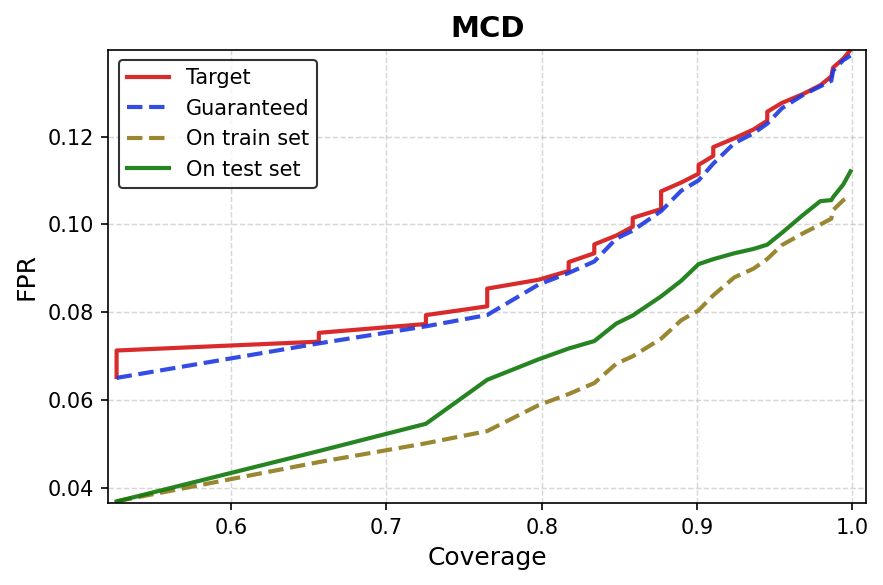

In [ ]:
metric_plots(
    all_results,
    metric="FPR",
    lines_list=lines_list_2_MCD,
    xlim=[0.99 * min(results_MCD.test_coverage), 1.01 * max(results_MCD.test_coverage)],
    ylim=[0.99 * min(results_MCD.test_metric), 1.01 * max(results_MCD.metric_bound)],
    title="MCD",
)

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

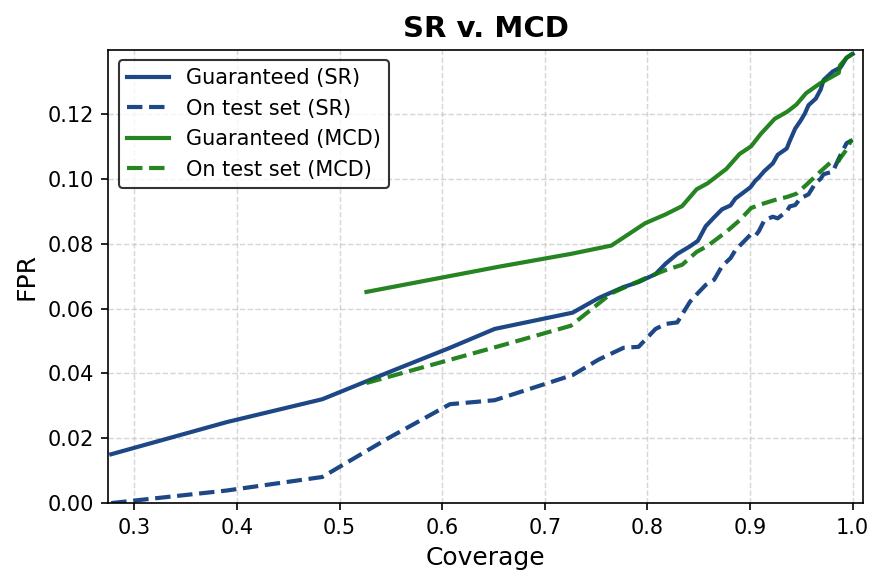

In [ ]:
metric_plots(
    all_results,
    metric="FPR",
    lines_list=lines_list_2,
    xlim=[
        0.99 * min(min(results_SR.test_coverage), min(results_MCD.test_coverage)),
        1.01 * max(max(results_MCD.test_coverage), max(results_SR.test_coverage)),
    ],
    ylim=[
        0.99 * min(min(results_MCD.test_metric), min(results_SR.test_metric)),
        1.01 * max(max(results_MCD.metric_bound), max(results_SR.metric_bound)),
    ],
    title="SR v. MCD",
)

### 2.2. __FNR__

In [ ]:
metric_targets = np.linspace(0.001, 0.05, num=num_targets)

In [ ]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=22
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
train_set_MCD, test_set_MCD = train_test_split(
    sgp_df_MCD, seed=22
)  # same with MCD kappa confidence function
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="FNR",
    mode="greedy",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
results_MCD = sgp_at_targets(
    train_set_MCD,
    test_set_MCD,
    metric_targets=metric_targets,
    metric="FNR",
    mode="greedy",
    theta_min=theta_min_MCD,
    theta_max=theta_max_MCD,
)
all_results = {"SR": results_SR, "MCD": results_MCD}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

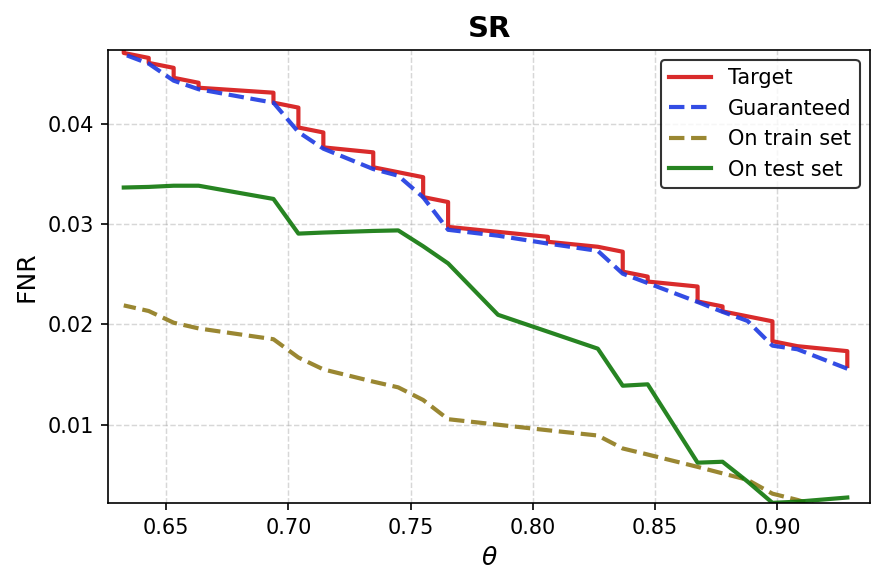

In [ ]:
metric_plots(
    all_results,
    metric="FNR",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * min(results_SR.theta_star), 1.01 * max(results_SR.theta_star)],
    ylim=[0.99 * min(results_SR.test_metric), 1.01 * max(results_SR.metric_bound)],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

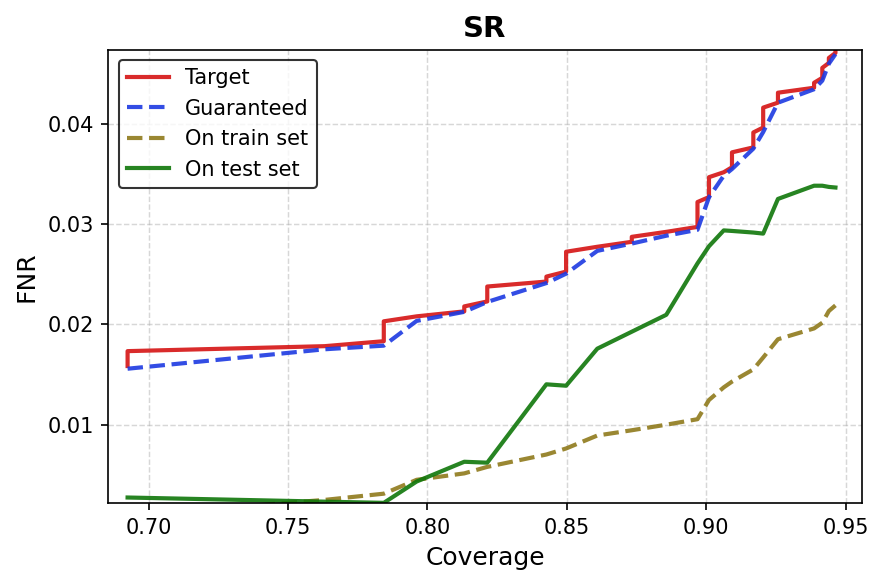

In [ ]:
metric_plots(
    all_results,
    metric="FNR",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[0.99 * min(results_SR.test_metric), 1.01 * max(results_SR.metric_bound)],
    title="SR",
)

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

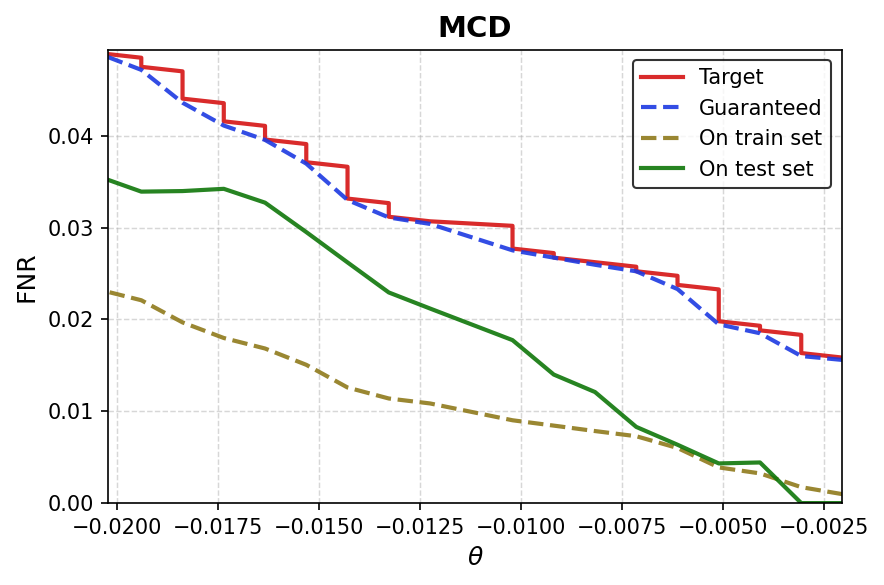

In [ ]:
metric_plots(
    all_results,
    metric="FNR",
    lines_list=lines_list_1_MCD,
    xlim=[0.99 * min(results_MCD.theta_star), 1.01 * max(results_MCD.theta_star)],
    ylim=[0.99 * min(results_MCD.test_metric), 1.01 * max(results_MCD.metric_bound)],
    title="MCD",
)

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

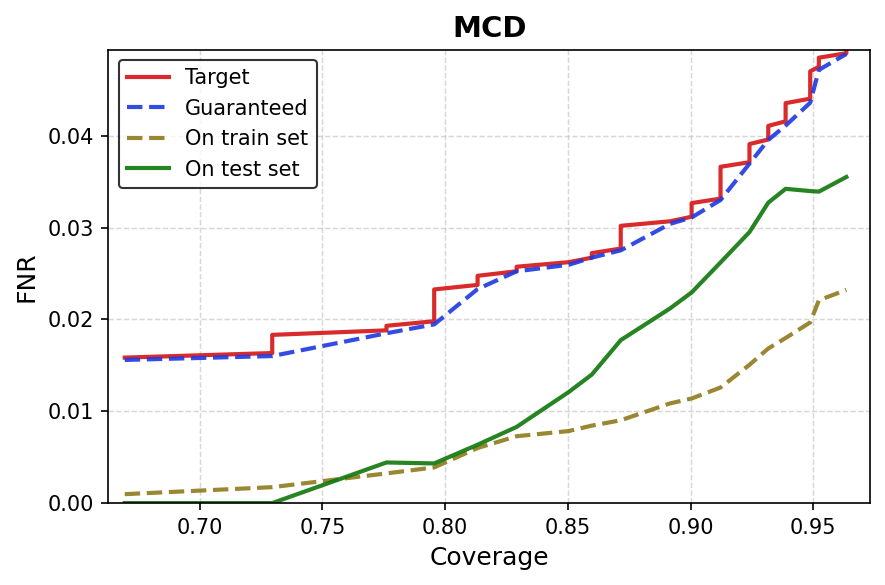

In [ ]:
metric_plots(
    all_results,
    metric="FNR",
    lines_list=lines_list_2_MCD,
    xlim=[0.99 * min(results_MCD.test_coverage), 1.01 * max(results_MCD.test_coverage)],
    ylim=[0.99 * min(results_MCD.test_metric), 1.01 * max(results_MCD.metric_bound)],
    title="MCD",
)

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

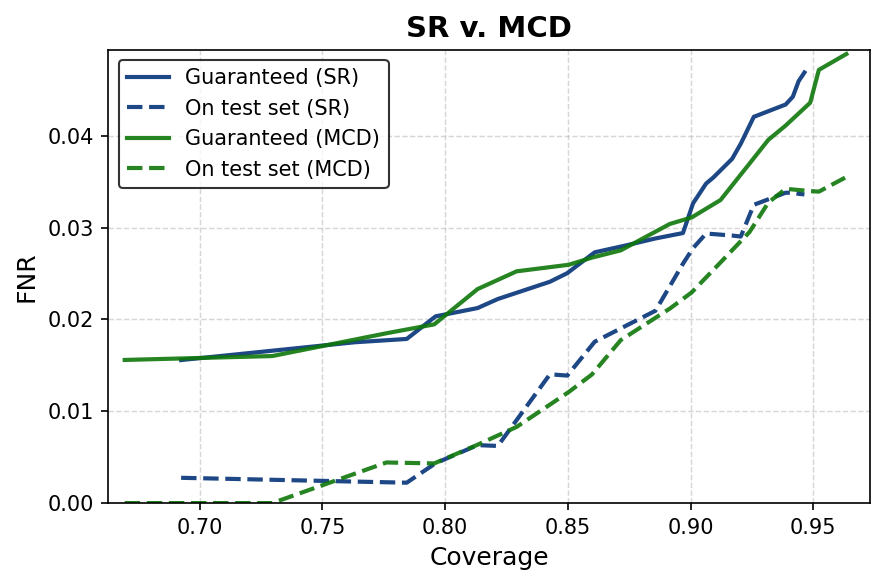

In [ ]:
metric_plots(
    all_results,
    metric="FNR",
    lines_list=lines_list_2,
    xlim=[
        0.99 * min(min(results_SR.test_coverage), min(results_MCD.test_coverage)),
        1.01 * max(max(results_MCD.test_coverage), max(results_SR.test_coverage)),
    ],
    ylim=[
        0.99 * min(min(results_MCD.test_metric), min(results_SR.test_metric)),
        1.01 * max(max(results_MCD.metric_bound), max(results_SR.metric_bound)),
    ],
    title="SR v. MCD",
)

### 2.3. __PPV__

In [ ]:
metric_targets = np.linspace(0.65, 0.99, num=num_targets)

In [ ]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=23
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
train_set_MCD, test_set_MCD = train_test_split(
    sgp_df_MCD, seed=23
)  # same with MCD kappa confidence function
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="PPV",
    mode="greedy",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
results_MCD = sgp_at_targets(
    train_set_MCD,
    test_set_MCD,
    metric_targets=metric_targets,
    metric="PPV",
    mode="greedy",
    theta_min=theta_min_MCD,
    theta_max=theta_max_MCD,
)
all_results = {"SR": results_SR, "MCD": results_MCD}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

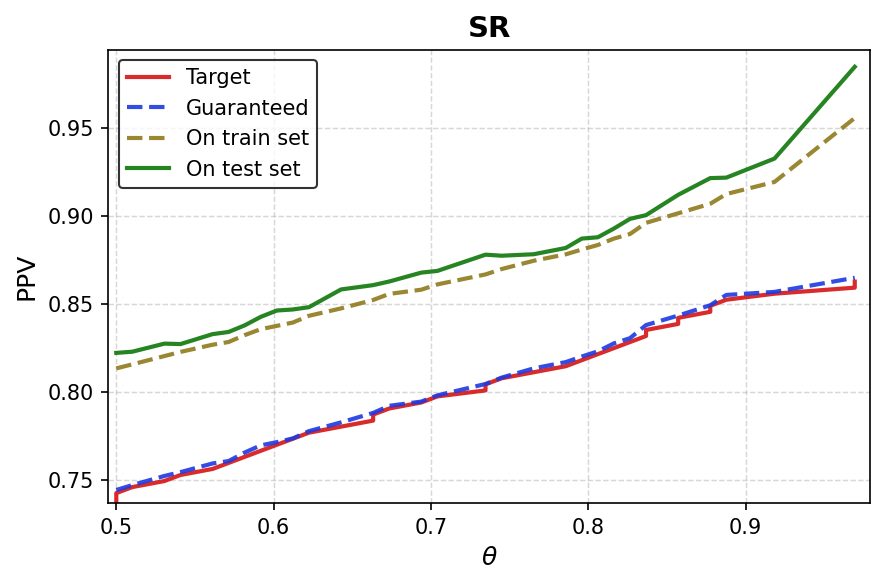

In [ ]:
metric_plots(
    all_results,
    metric="PPV",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * min(results_SR.theta_star), 1.01 * max(results_SR.theta_star)],
    ylim=[
        0.99 * min(results_SR.metric_bound),
        min(1, 1.01 * max(max(results_SR.test_metric), max(results_SR.train_metric))),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

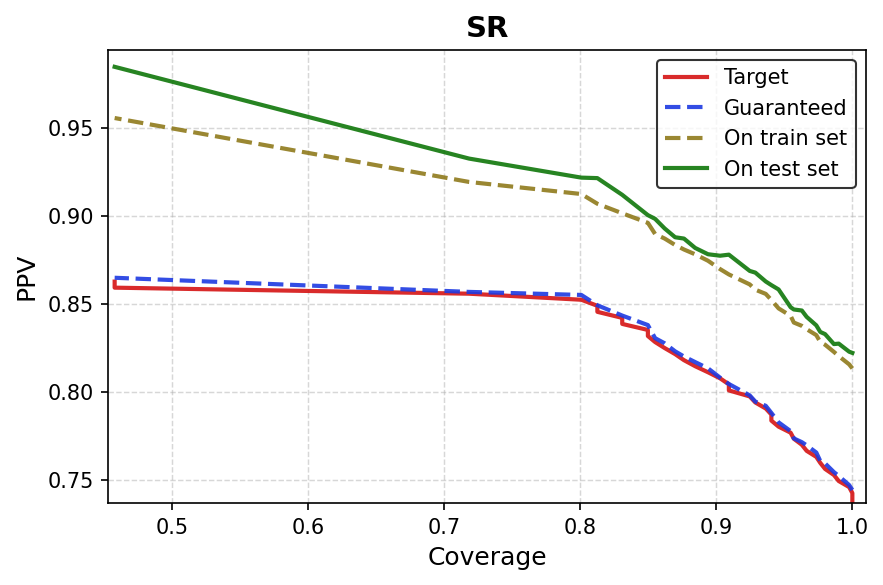

In [ ]:
metric_plots(
    all_results,
    metric="PPV",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[
        0.99 * min(results_SR.metric_bound),
        min(1, 1.01 * max(max(results_SR.test_metric), max(results_SR.train_metric))),
    ],
    title="SR",
)

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

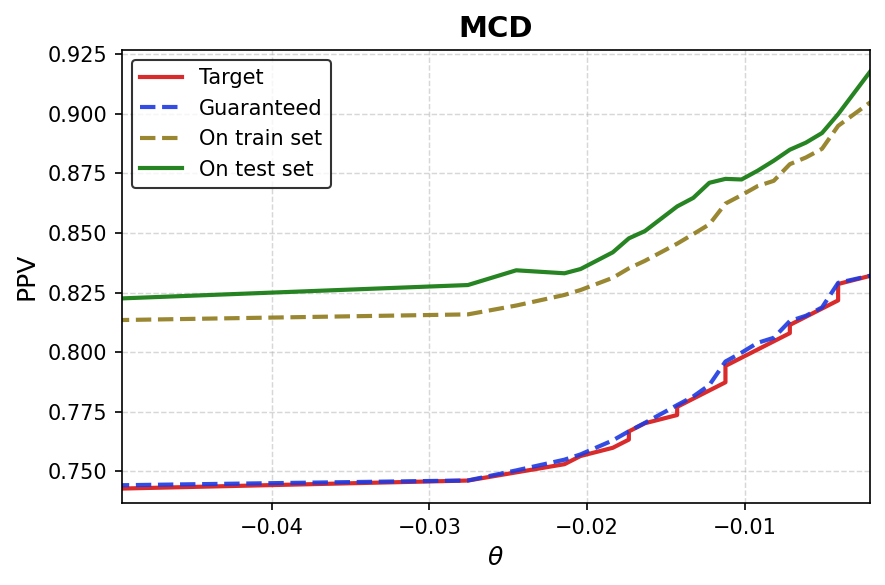

In [ ]:
metric_plots(
    all_results,
    metric="PPV",
    lines_list=lines_list_1_MCD,
    xlim=[0.99 * min(results_MCD.theta_star), 1.01 * max(results_MCD.theta_star)],
    ylim=[
        0.99 * min(results_MCD.metric_bound),
        min(1, 1.01 * max(max(results_MCD.test_metric), max(results_MCD.train_metric))),
    ],
    title="MCD",
)

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

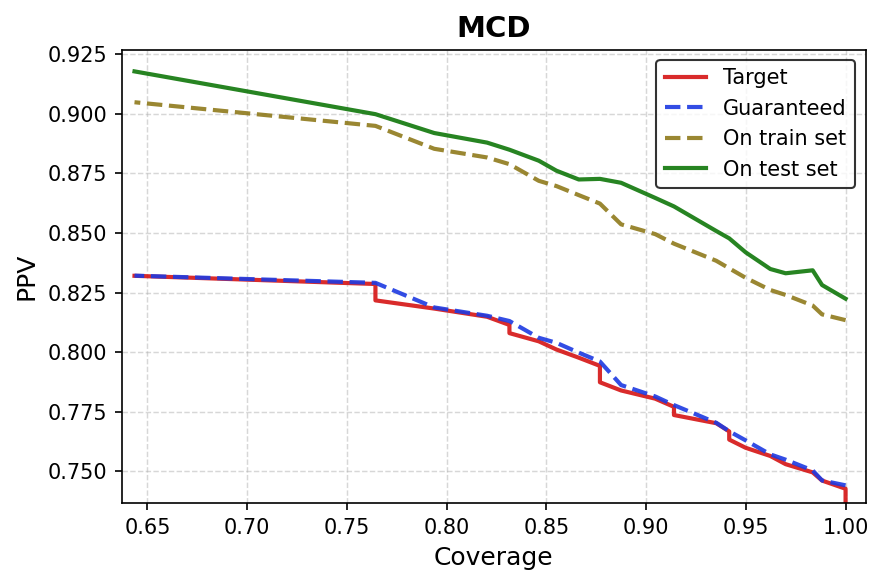

In [ ]:
metric_plots(
    all_results,
    metric="PPV",
    lines_list=lines_list_2_MCD,
    xlim=[0.99 * min(results_MCD.test_coverage), 1.01 * max(results_MCD.test_coverage)],
    ylim=[
        0.99 * min(results_MCD.metric_bound),
        min(1, 1.01 * max(max(results_MCD.test_metric), max(results_MCD.train_metric))),
    ],
    title="MCD",
)

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

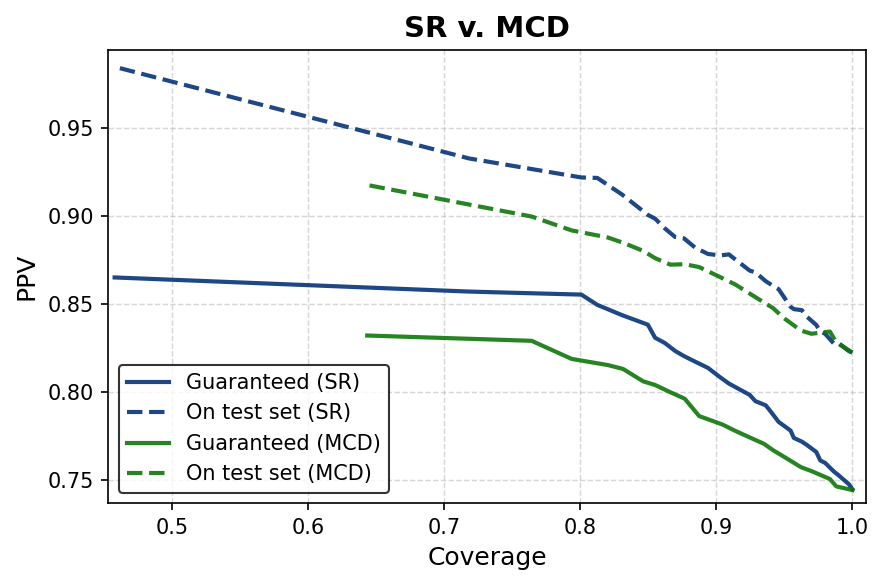

In [ ]:
metric_plots(
    all_results,
    metric="PPV",
    lines_list=lines_list_2,
    xlim=[
        0.99 * min(min(results_SR.test_coverage), min(results_MCD.test_coverage)),
        1.01 * max(max(results_SR.test_coverage), max(results_MCD.test_coverage)),
    ],
    ylim=[
        0.99 * min(min(results_MCD.metric_bound), min(results_SR.metric_bound)),
        1.01 * max(max(results_MCD.test_metric), max(results_SR.test_metric)),
    ],
    title="SR v. MCD",
)

### 2.4. __SE__

In [ ]:
metric_targets = np.linspace(0.95, 0.999, num=num_targets)

In [ ]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=24
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
train_set_MCD, test_set_MCD = train_test_split(
    sgp_df_MCD, seed=24
)  # same with MCD kappa confidence function
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="SE",
    mode="greedy",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
results_MCD = sgp_at_targets(
    train_set_MCD,
    test_set_MCD,
    metric_targets=metric_targets,
    metric="SE",
    mode="greedy",
    theta_min=theta_min_MCD,
    theta_max=theta_max_MCD,
)
all_results = {"SR": results_SR, "MCD": results_MCD}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

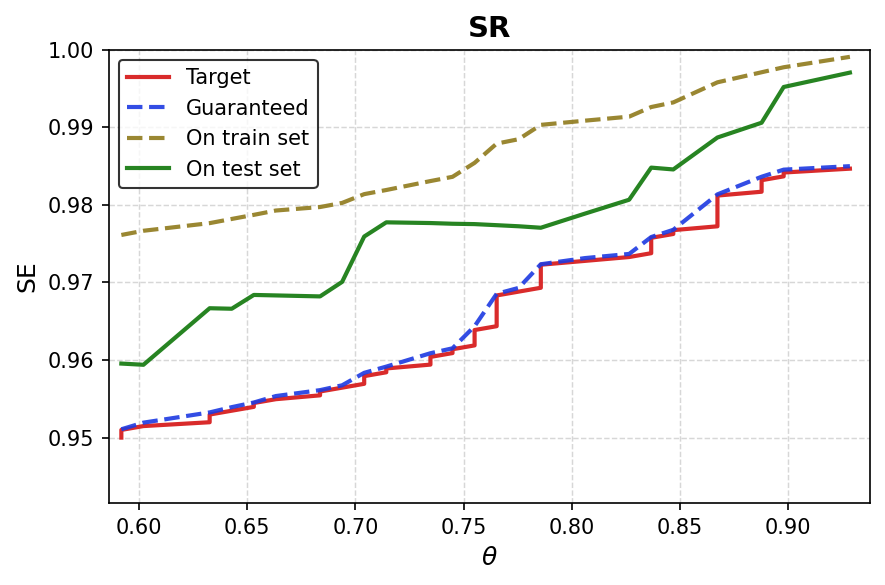

In [ ]:
metric_plots(
    all_results,
    metric="SE",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * min(results_SR.theta_star), 1.01 * max(results_SR.theta_star)],
    ylim=[
        0.99 * min(results_SR.metric_bound),
        min(1, 1.01 * max(max(results_SR.test_metric), max(results_SR.train_metric))),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

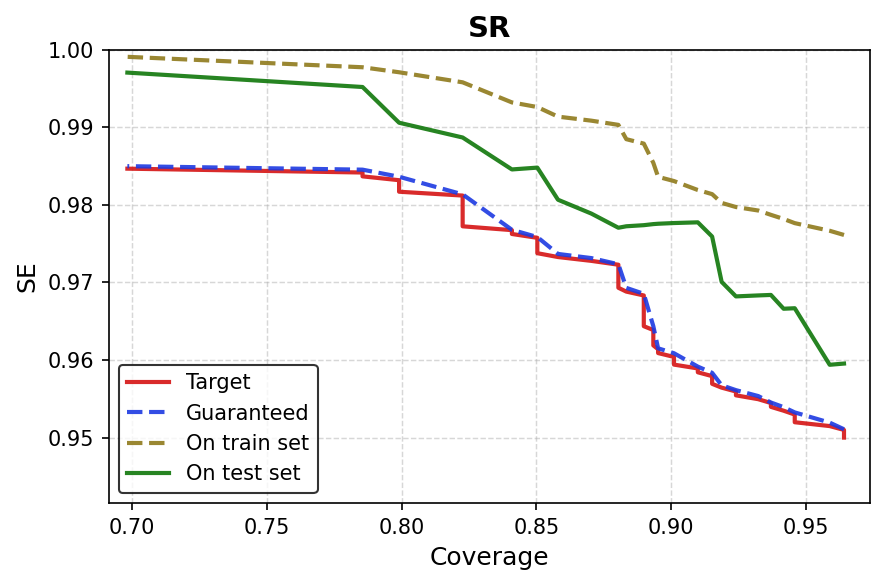

In [ ]:
metric_plots(
    all_results,
    metric="SE",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[
        0.99 * min(results_SR.metric_bound),
        min(1, 1.01 * max(max(results_SR.test_metric), max(results_SR.train_metric))),
    ],
    title="SR",
)

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

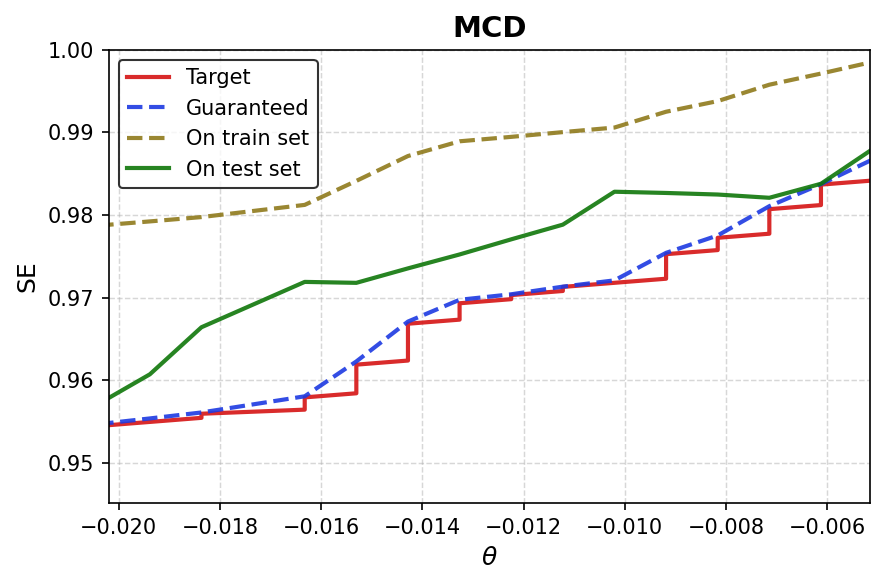

In [ ]:
metric_plots(
    all_results,
    metric="SE",
    lines_list=lines_list_1_MCD,
    xlim=[0.99 * min(results_MCD.theta_star), 1.01 * max(results_MCD.theta_star)],
    ylim=[
        0.99 * min(results_MCD.metric_bound),
        min(1, 1.01 * max(max(results_MCD.test_metric), max(results_MCD.train_metric))),
    ],
    title="MCD",
)

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

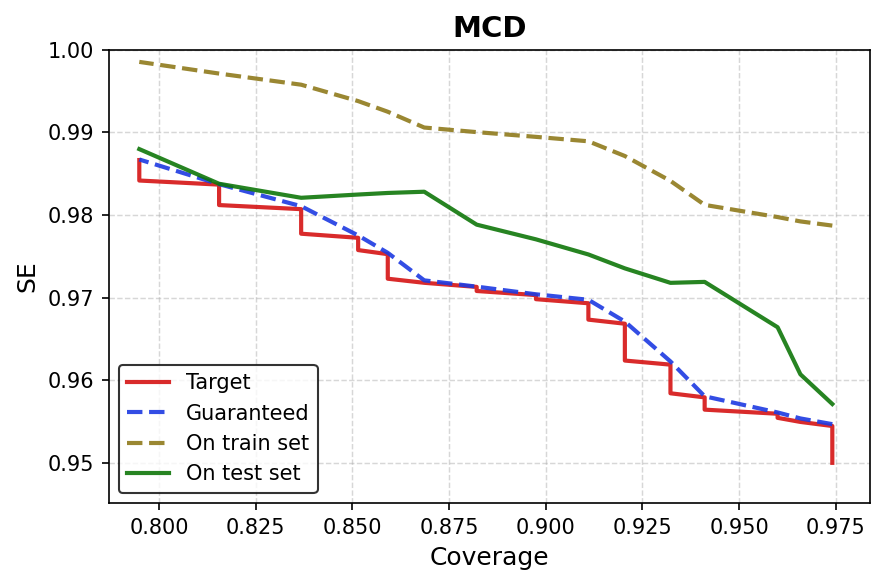

In [ ]:
metric_plots(
    all_results,
    metric="SE",
    lines_list=lines_list_2_MCD,
    xlim=[0.99 * min(results_MCD.test_coverage), 1.01 * max(results_MCD.test_coverage)],
    ylim=[
        0.99 * min(results_MCD.metric_bound),
        min(1, 1.01 * max(max(results_MCD.test_metric), max(results_MCD.train_metric))),
    ],
    title="MCD",
)

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

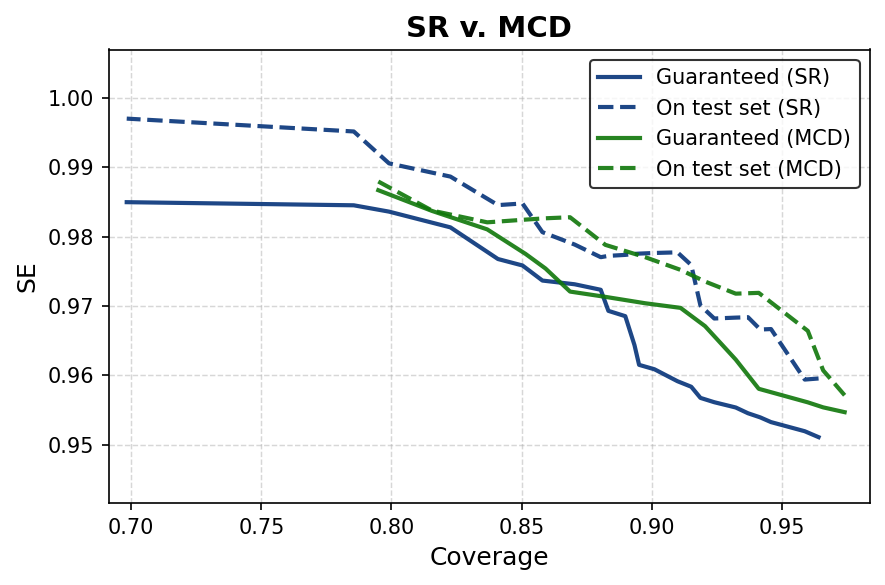

In [ ]:
metric_plots(
    all_results,
    metric="SE",
    lines_list=lines_list_2,
    xlim=[
        0.99 * min(min(results_SR.test_coverage), min(results_MCD.test_coverage)),
        1.01 * max(max(results_SR.test_coverage), max(results_MCD.test_coverage)),
    ],
    ylim=[
        0.99 * min(min(results_MCD.metric_bound), min(results_SR.metric_bound)),
        1.01 * max(max(results_MCD.test_metric), max(results_SR.test_metric)),
    ],
    title="SR v. MCD",
)

### 2.5. __SP__

In [ ]:
metric_targets = np.linspace(0.8, 0.999, num=num_targets)

In [ ]:
train_set_SR, test_set_SR = train_test_split(
    sgp_df_SR, seed=25
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
train_set_MCD, test_set_MCD = train_test_split(
    sgp_df_MCD, seed=25
)  # same with MCD kappa confidence function
results_SR = sgp_at_targets(
    train_set_SR,
    test_set_SR,
    metric_targets=metric_targets,
    metric="SP",
    mode="greedy",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
results_MCD = sgp_at_targets(
    train_set_MCD,
    test_set_MCD,
    metric_targets=metric_targets,
    metric="SP",
    mode="greedy",
    theta_min=theta_min_MCD,
    theta_max=theta_max_MCD,
)
all_results = {"SR": results_SR, "MCD": results_MCD}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

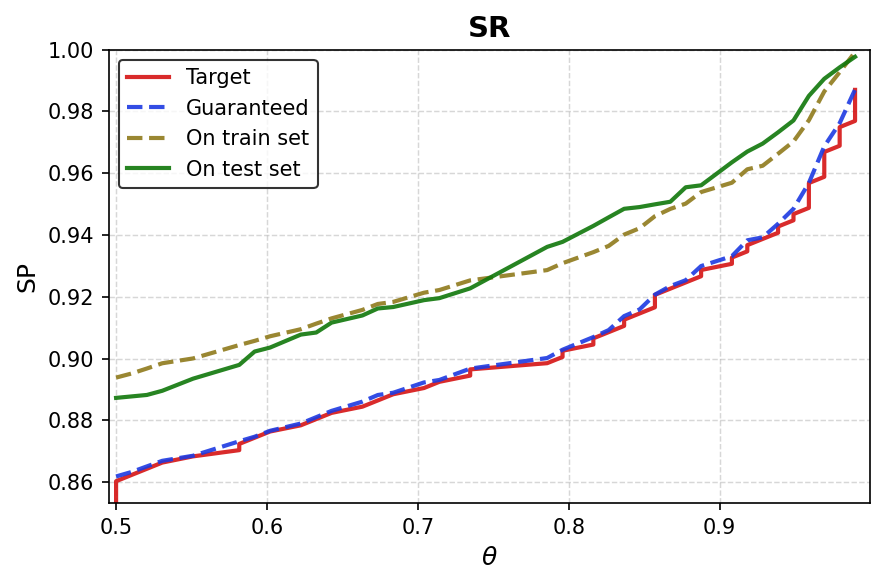

In [ ]:
metric_plots(
    all_results,
    metric="SP",
    lines_list=lines_list_1_SR,
    xlim=[0.99 * min(results_SR.theta_star), 1.01 * max(results_SR.theta_star)],
    ylim=[
        0.99 * min(results_SR.metric_bound),
        min(1, 1.01 * max(max(results_SR.test_metric), max(results_SR.train_metric))),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

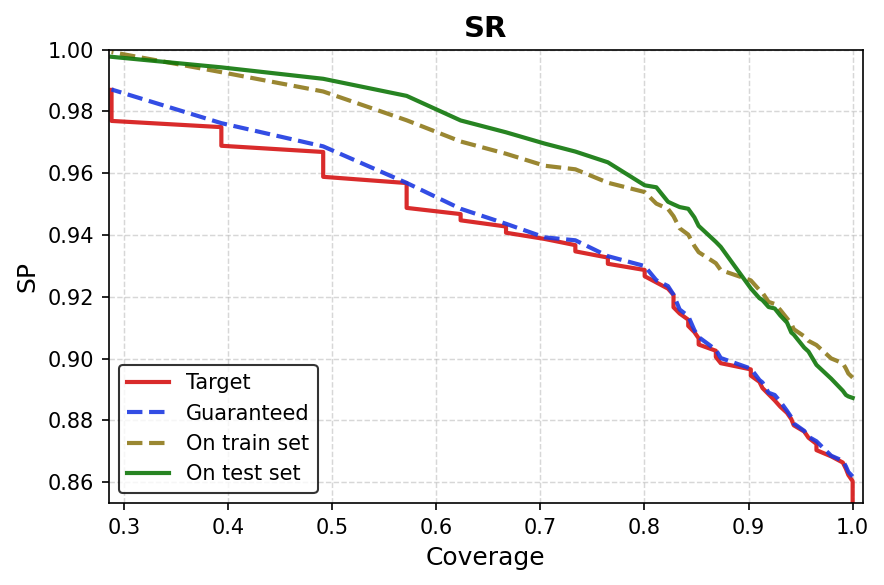

In [ ]:
metric_plots(
    all_results,
    metric="SP",
    lines_list=lines_list_2_SR,
    xlim=[0.99 * min(results_SR.test_coverage), 1.01 * max(results_SR.test_coverage)],
    ylim=[
        0.99 * min(results_SR.metric_bound),
        min(1, 1.01 * max(max(results_SR.test_metric), max(results_SR.train_metric))),
    ],
    title="SR",
)

Curves w.r.t. $\theta$, using Monte Carlo Dropout (MCD) minus variance as confidence function

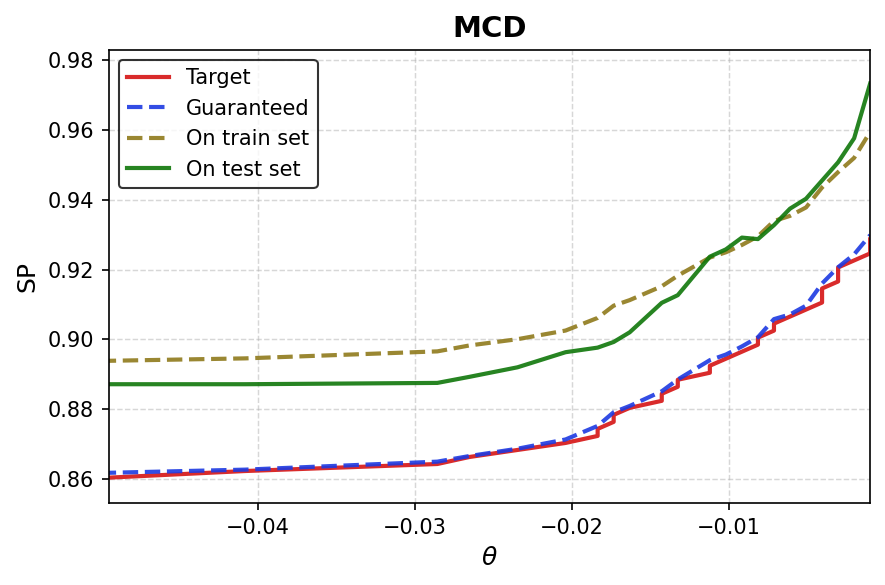

In [ ]:
metric_plots(
    all_results,
    metric="SP",
    lines_list=lines_list_1_MCD,
    xlim=[0.99 * min(results_MCD.theta_star), 1.01 * max(results_MCD.theta_star)],
    ylim=[
        0.99 * min(results_MCD.metric_bound),
        min(1, 1.01 * max(max(results_MCD.test_metric), max(results_MCD.train_metric))),
    ],
    title="MCD",
)

Curves w.r.t. coverage, using Monte Carlo Dropout (MCD) minus variance as confidence function

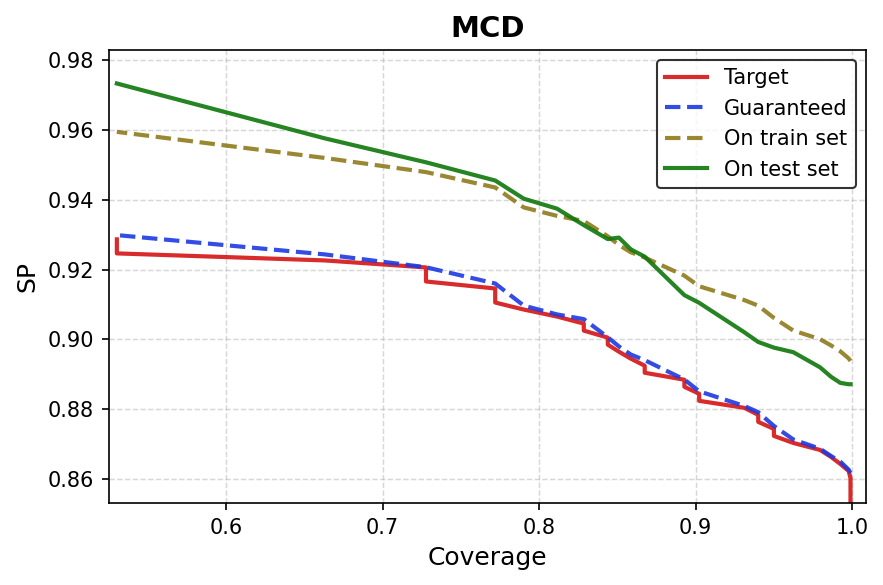

In [ ]:
metric_plots(
    all_results,
    metric="SP",
    lines_list=lines_list_2_MCD,
    xlim=[0.99 * min(results_MCD.test_coverage), 1.01 * max(results_MCD.test_coverage)],
    ylim=[
        0.99 * min(results_MCD.metric_bound),
        min(1, 1.01 * max(max(results_MCD.test_metric), max(results_MCD.train_metric))),
    ],
    title="MCD",
)

Bounds and test set estimates w.r.t. coverage, SR v. MCD 

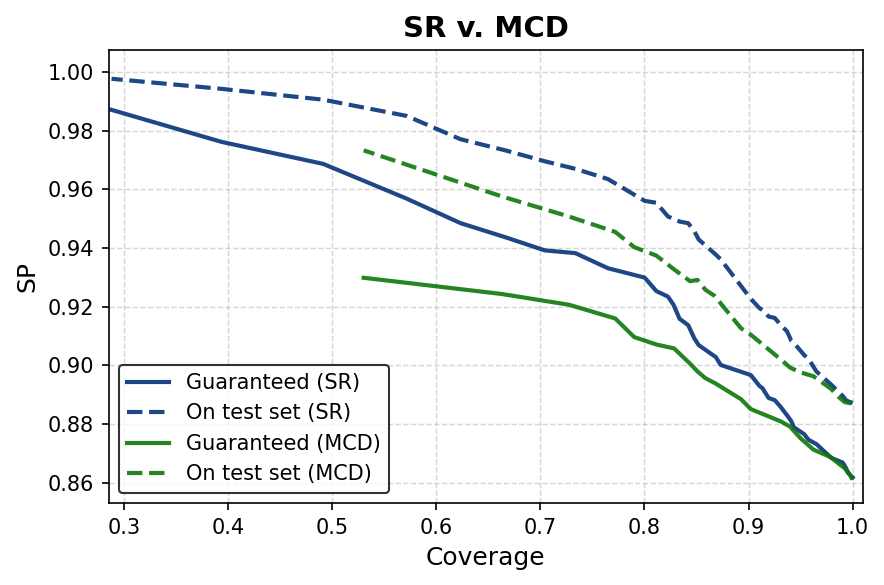

In [ ]:
metric_plots(
    all_results,
    metric="SP",
    lines_list=lines_list_2,
    xlim=[
        0.99 * min(min(results_SR.test_coverage), min(results_MCD.test_coverage)),
        1.01 * max(max(results_SR.test_coverage), max(results_MCD.test_coverage)),
    ],
    ylim=[
        0.99 * min(min(results_MCD.metric_bound), min(results_SR.metric_bound)),
        1.01 * max(max(results_MCD.test_metric), max(results_SR.test_metric)),
    ],
    title="SR v. MCD",
)